In [2]:
!pip install -q datasets transformers

In [3]:


import os, gc, time, math, copy, random, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
from torch.utils.data import DataLoader
from datasets import load_dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    get_linear_schedule_with_warmup,
)

warnings.filterwarnings("ignore")

MODEL_NAME = "prajjwal1/bert-tiny"

MAX_LENGTH = 128
BATCH_SIZE = 32
VAL_BATCH_SIZE = 64
EPOCHS = 3

WEIGHT_DECAY = 0.01
WARMUP_RATIO = 0.10
GRAD_CLIP = 1.0

DEBUG_SIZE = 5000
LOG_INTERVAL = 50

FINAL_SEEDS = [42, 43, 44]

OUTPUT_DIR = "/kaggle/working/results"
os.makedirs(OUTPUT_DIR, exist_ok=True)

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("PyTorch:", torch.__version__)
print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

print("Built-in Muon:", hasattr(torch.optim, "Muon"))

PyTorch: 2.10.0+cu128
Device: cuda
GPU: Tesla T4
Built-in Muon: True


In [4]:
dataset = load_dataset("glue", "sst2")

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize(batch):
    return tokenizer(
        batch["sentence"],
        truncation=True,
        padding="max_length",
        max_length=MAX_LENGTH,
    )

tokenized = dataset.map(
    tokenize,
    batched=True
)

# Remove columns we don't need
remove_cols = [
    c for c in ["sentence", "idx"]
    if c in tokenized["train"].column_names
]

tokenized = tokenized.remove_columns(remove_cols)

if "label" in tokenized["train"].column_names:
    tokenized = tokenized.rename_column(
        "label",
        "labels"
    )


def collate_batch(examples):
    batch = {}

    for key in [
        "input_ids",
        "attention_mask",
        "token_type_ids",
        "labels",
    ]:
        if key in examples[0]:
            batch[key] = torch.tensor(
                [x[key] for x in examples],
                dtype=torch.long
            )

    return batch


def create_loaders(seed, debug=False):

    train_ds = tokenized["train"]
    val_ds = tokenized["validation"]

    if debug:
        train_ds = train_ds.select(
            range(min(DEBUG_SIZE, len(train_ds)))
        )

    generator = torch.Generator()
    generator.manual_seed(seed)

    train_loader = DataLoader(
        train_ds,
        batch_size=BATCH_SIZE,
        shuffle=True,
        generator=generator,
        collate_fn=collate_batch,
    )

    val_loader = DataLoader(
        val_ds,
        batch_size=VAL_BATCH_SIZE,
        shuffle=False,
        collate_fn=collate_batch,
    )

    return train_loader, val_loader


# Test immediately
train_loader, val_loader = create_loaders(
    seed=42,
    debug=True
)

batch = next(iter(train_loader))

for k, v in batch.items():
    print(k, type(v), v.shape)

README.md: 0.00B [00:00, ?B/s]

sst2/train-00000-of-00001.parquet:   0%|          | 0.00/3.11M [00:00<?, ?B/s]

sst2/validation-00000-of-00001.parquet:   0%|          | 0.00/72.8k [00:00<?, ?B/s]

sst2/test-00000-of-00001.parquet:   0%|          | 0.00/148k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/67349 [00:00<?, ? examples/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

Map:   0%|          | 0/67349 [00:00<?, ? examples/s]

Map:   0%|          | 0/872 [00:00<?, ? examples/s]

Map:   0%|          | 0/1821 [00:00<?, ? examples/s]

input_ids <class 'torch.Tensor'> torch.Size([32, 128])
attention_mask <class 'torch.Tensor'> torch.Size([32, 128])
token_type_ids <class 'torch.Tensor'> torch.Size([32, 128])
labels <class 'torch.Tensor'> torch.Size([32])


In [5]:
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def move_batch(batch):
    return {
        k: v.to(device)
        for k, v in batch.items()
    }


def create_model(seed):
    set_seed(seed)

    return AutoModelForSequenceClassification.from_pretrained(
        MODEL_NAME,
        num_labels=2
    ).to(device)


@torch.no_grad()
def evaluate(model, loader):

    model.eval()

    total_loss = 0
    total_correct = 0
    total_examples = 0

    for batch in loader:

        batch = move_batch(batch)

        outputs = model(**batch)

        bs = batch["labels"].size(0)

        total_loss += outputs.loss.item() * bs

        predictions = outputs.logits.argmax(dim=-1)

        total_correct += (
            predictions == batch["labels"]
        ).sum().item()

        total_examples += bs

    return {
        "val_loss": total_loss / total_examples,
        "val_accuracy": total_correct / total_examples
    }


def grad_norm(model):

    total = 0.0

    for p in model.parameters():

        if p.grad is not None:
            total += p.grad.detach().norm().item() ** 2

    return total ** 0.5


@torch.no_grad()
def param_norm(model):

    return sum(
        p.detach().norm().item() ** 2
        for p in model.parameters()
        if p.requires_grad
    ) ** 0.5


@torch.no_grad()
def snapshot(model):

    return {
        n: p.detach().clone()
        for n, p in model.named_parameters()
        if p.requires_grad
    }


@torch.no_grad()
def update_norm(model, before):

    return sum(
        (
            p.detach() - before[n]
        ).norm().item() ** 2

        for n, p in model.named_parameters()

        if n in before
    ) ** 0.5

In [6]:
def adamw_groups(named_params):

    decay = []
    no_decay = []

    for name, p in named_params:

        if not p.requires_grad:
            continue

        if (
            p.ndim == 1
            or "bias" in name.lower()
            or "layernorm" in name.lower()
        ):
            no_decay.append(p)

        else:
            decay.append(p)

    return [
        {
            "params": decay,
            "weight_decay": WEIGHT_DECAY
        },
        {
            "params": no_decay,
            "weight_decay": 0.0
        }
    ]


def split_muon_params(model):

    muon_named = []
    fallback_named = []

    for name, p in model.named_parameters():

        if not p.requires_grad:
            continue

        # Restrict Muon to hidden transformer matrices
        if (
            p.ndim == 2
            and name.startswith("bert.encoder.layer")
        ):
            muon_named.append((name, p))

        else:
            fallback_named.append((name, p))

    return muon_named, fallback_named


# Inspect once
test_model = create_model(42)

muon_named, fallback_named = split_muon_params(test_model)

print("Muon tensors:", len(muon_named))
print("Fallback tensors:", len(fallback_named))

print("\nExample Muon parameters:")
for name, p in muon_named[:8]:
    print(name, tuple(p.shape))

del test_model
torch.cuda.empty_cache()

pytorch_model.bin:   0%|          | 0.00/17.8M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/39 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: prajjwal1/bert-tiny
Key                                        | Status     | 
-------------------------------------------+------------+-
bert.embeddings.position_ids               | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect i

model.safetensors:   0%|          | 0.00/17.7M [00:00<?, ?B/s]

Muon tensors: 12
Fallback tensors: 29

Example Muon parameters:
bert.encoder.layer.0.attention.self.query.weight (128, 128)
bert.encoder.layer.0.attention.self.key.weight (128, 128)
bert.encoder.layer.0.attention.self.value.weight (128, 128)
bert.encoder.layer.0.attention.output.dense.weight (128, 128)
bert.encoder.layer.0.intermediate.dense.weight (512, 128)
bert.encoder.layer.0.output.dense.weight (128, 512)
bert.encoder.layer.1.attention.self.query.weight (128, 128)
bert.encoder.layer.1.attention.self.key.weight (128, 128)


In [7]:
@torch.no_grad()
def newton_schulz(G, steps=5, eps=1e-7):

    a = 3.4445
    b = -4.775
    c = 2.0315

    X = G.float()

    X /= X.norm() + eps

    transposed = False

    if X.shape[0] > X.shape[1]:
        X = X.T
        transposed = True

    for _ in range(steps):

        A = X @ X.T

        X = (
            a * X
            + (b * A + c * (A @ A)) @ X
        )

    if transposed:
        X = X.T

    return X


class LocalMuon(torch.optim.Optimizer):

    def __init__(
        self,
        params,
        lr=1e-3,
        momentum=0.95,
        weight_decay=0.01
    ):

        super().__init__(
            params,
            dict(
                lr=lr,
                momentum=momentum,
                weight_decay=weight_decay
            )
        )

    @torch.no_grad()
    def step(self):

        for group in self.param_groups:

            lr = group["lr"]
            momentum = group["momentum"]
            wd = group["weight_decay"]

            for p in group["params"]:

                if p.grad is None:
                    continue

                state = self.state[p]

                if "buffer" not in state:
                    state["buffer"] = torch.zeros_like(
                        p.grad
                    )

                buf = state["buffer"]

                buf.mul_(momentum).add_(p.grad)

                update = (
                    p.grad
                    + momentum * buf
                )

                update = newton_schulz(update)

                scale = math.sqrt(
                    max(
                        1.0,
                        p.shape[0] / p.shape[1]
                    )
                )

                update *= scale

                p.mul_(1 - lr * wd)

                p.add_(
                    update.to(p.dtype),
                    alpha=-lr
                )


def make_optimizers(
    model,
    optimizer_name,
    main_lr,
    fallback_lr=None
):

    if optimizer_name == "adamw":

        optimizer = torch.optim.AdamW(
            adamw_groups(
                list(model.named_parameters())
            ),
            lr=main_lr
        )

        return [optimizer]

    muon_named, fallback_named = (
        split_muon_params(model)
    )

    muon_params = [
        p for _, p in muon_named
    ]

    if hasattr(torch.optim, "Muon"):

        muon_optimizer = torch.optim.Muon(
            muon_params,
            lr=main_lr,
            momentum=0.95,
            weight_decay=WEIGHT_DECAY,
        )

    else:

        muon_optimizer = LocalMuon(
            muon_params,
            lr=main_lr,
            momentum=0.95,
            weight_decay=WEIGHT_DECAY,
        )

    fallback_optimizer = torch.optim.AdamW(
        adamw_groups(fallback_named),
        lr=fallback_lr
    )

    return [
        muon_optimizer,
        fallback_optimizer
    ]

In [8]:
def train_run(
    optimizer_name,
    seed,
    main_lr,
    fallback_lr=None,
    epochs=3,
    debug=False
):

    set_seed(seed)

    model = create_model(seed)

    train_loader, val_loader = create_loaders(
        seed,
        debug
    )

    optimizers = make_optimizers(
        model,
        optimizer_name,
        main_lr,
        fallback_lr
    )

    total_steps = len(train_loader) * epochs
    warmup_steps = int(WARMUP_RATIO * total_steps)

    schedulers = [
        get_linear_schedule_with_warmup(
            opt,
            warmup_steps,
            total_steps
        )
        for opt in optimizers
    ]

    step_rows = []
    epoch_rows = []

    global_step = 0
    start = time.time()

    for epoch in range(epochs):

        model.train()

        total_train_loss = 0
        total_examples = 0

        for batch in train_loader:

            global_step += 1

            batch = move_batch(batch)

            for opt in optimizers:
                opt.zero_grad(set_to_none=True)

            outputs = model(**batch)

            loss = outputs.loss

            loss.backward()

            should_log = (
                global_step % LOG_INTERVAL == 0
            )

            if should_log:
                gnorm = grad_norm(model)

            torch.nn.utils.clip_grad_norm_(
                model.parameters(),
                GRAD_CLIP
            )

            if should_log:
                before = snapshot(model)
                pnorm = param_norm(model)

            for opt in optimizers:
                opt.step()

            if should_log:

                unorm = update_norm(
                    model,
                    before
                )

                step_rows.append({
                    "optimizer": optimizer_name,
                    "seed": seed,
                    "epoch": epoch + 1,
                    "step": global_step,
                    "train_loss": loss.item(),
                    "grad_norm": gnorm,
                    "update_norm": unorm,
                    "relative_update":
                        unorm / (pnorm + 1e-12)
                })

            for scheduler in schedulers:
                scheduler.step()

            bs = batch["labels"].size(0)

            total_train_loss += (
                loss.item() * bs
            )

            total_examples += bs

        train_loss = (
            total_train_loss
            / total_examples
        )

        metrics = evaluate(
            model,
            val_loader
        )

        epoch_rows.append({
            "optimizer": optimizer_name,
            "seed": seed,
            "epoch": epoch + 1,
            "main_lr": main_lr,
            "fallback_lr": fallback_lr,
            "train_loss": train_loss,
            "val_loss": metrics["val_loss"],
            "val_accuracy":
                metrics["val_accuracy"],
            "runtime":
                time.time() - start
        })

        print(
            optimizer_name.upper(),
            "| seed", seed,
            "| epoch", epoch + 1,
            "| train", round(train_loss, 4),
            "| val", round(metrics["val_loss"], 4),
            "| acc", round(metrics["val_accuracy"], 4)
        )

    return (
        model,
        pd.DataFrame(step_rows),
        pd.DataFrame(epoch_rows)
    )

In [9]:
# AdamW debug
adam_model, adam_steps, adam_epochs = train_run(
    optimizer_name="adamw",
    seed=42,
    main_lr=2e-5,
    epochs=1,
    debug=True
)

display(adam_epochs)

del adam_model
torch.cuda.empty_cache()


# Muon debug
muon_model, muon_steps, muon_epochs = train_run(
    optimizer_name="muon",
    seed=42,
    main_lr=1e-3,
    fallback_lr=2e-5,
    epochs=1,
    debug=True
)

display(muon_epochs)

del muon_model
torch.cuda.empty_cache()
gc.collect()

Loading weights:   0%|          | 0/39 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: prajjwal1/bert-tiny
Key                                        | Status     | 
-------------------------------------------+------------+-
bert.embeddings.position_ids               | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect i

ADAMW | seed 42 | epoch 1 | train 0.6769 | val 0.6729 | acc 0.5791


,optimizer,seed,epoch,main_lr,fallback_lr,train_loss,val_loss,val_accuracy,runtime
0,adamw,42,1,0.00002,None,0.676862,0.672885,0.579128,3.595695


Loading weights:   0%|          | 0/39 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: prajjwal1/bert-tiny
Key                                        | Status     | 
-------------------------------------------+------------+-
bert.embeddings.position_ids               | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect i

MUON | seed 42 | epoch 1 | train 0.6667 | val 0.6541 | acc 0.6548


,optimizer,seed,epoch,main_lr,fallback_lr,train_loss,val_loss,val_accuracy,runtime
0,muon,42,1,0.001,0.00002,0.666685,0.654105,0.654817,3.623984


199

In [10]:
adam_candidates = [
    1e-5,
    2e-5,
    5e-5
]

muon_candidates = [
    3e-4,
    1e-3,
    3e-3
]


def lr_search():

    rows = []

    # AdamW
    for lr in adam_candidates:

        model, _, epochs_df = train_run(
            "adamw",
            seed=42,
            main_lr=lr,
            epochs=1,
            debug=False
        )

        r = epochs_df.iloc[-1].to_dict()

        rows.append(r)

        del model
        torch.cuda.empty_cache()

    adam_df = pd.DataFrame(rows)

    best_adam = (
        adam_df
        .sort_values("val_loss")
        .iloc[0]["main_lr"]
    )

    print("\nBest AdamW LR:", best_adam)


    # Muon
    rows = []

    for lr in muon_candidates:

        model, _, epochs_df = train_run(
            "muon",
            seed=42,
            main_lr=lr,
            fallback_lr=best_adam,
            epochs=1,
            debug=False
        )

        r = epochs_df.iloc[-1].to_dict()

        rows.append(r)

        del model
        torch.cuda.empty_cache()

    muon_df = pd.DataFrame(rows)

    best_muon = (
        muon_df
        .sort_values("val_loss")
        .iloc[0]["main_lr"]
    )

    print("Best Muon LR:", best_muon)

    return (
        float(best_adam),
        float(best_muon),
        adam_df,
        muon_df
    )


BEST_ADAM_LR, BEST_MUON_LR, adam_lr_results, muon_lr_results = lr_search()

display(adam_lr_results)
display(muon_lr_results)

Loading weights:   0%|          | 0/39 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: prajjwal1/bert-tiny
Key                                        | Status     | 
-------------------------------------------+------------+-
bert.embeddings.position_ids               | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect i

ADAMW | seed 42 | epoch 1 | train 0.5994 | val 0.5441 | acc 0.7466


Loading weights:   0%|          | 0/39 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: prajjwal1/bert-tiny
Key                                        | Status     | 
-------------------------------------------+------------+-
bert.embeddings.position_ids               | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect i

...

Loading weights:   0%|          | 0/39 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: prajjwal1/bert-tiny
Key                                        | Status     | 
-------------------------------------------+------------+-
bert.embeddings.position_ids               | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect i

MUON | seed 42 | epoch 1 | train 0.4078 | val 0.4395 | acc 0.8028
Best Muon LR: 0.003


,optimizer,seed,epoch,main_lr,fallback_lr,train_loss,val_loss,val_accuracy,runtime
0,adamw,42,1,0.00001,None,0.599354,0.544069,0.746560,32.842173
1,adamw,42,1,0.00002,None,0.522521,0.479199,0.776376,32.658999
2,adamw,42,1,0.00005,None,0.441476,0.440601,0.803899,32.727668


,optimizer,seed,epoch,main_lr,fallback_lr,train_loss,val_loss,val_accuracy,runtime
0,muon,42,1,0.0003,0.00005,0.458036,0.448012,0.800459,45.863235
1,muon,42,1,0.0010,0.00005,0.424125,0.444647,0.805046,45.475376
2,muon,42,1,0.0030,0.00005,0.407767,0.439491,0.802752,45.356322


In [11]:
all_steps = []
all_epochs = []
models = {}

for seed in FINAL_SEEDS:

    # AdamW
    model, steps, epochs_df = train_run(
        "adamw",
        seed,
        BEST_ADAM_LR,
        epochs=3
    )

    all_steps.append(steps)
    all_epochs.append(epochs_df)

    models[("AdamW", seed)] = copy.deepcopy(
        model.cpu()
    )

    del model
    torch.cuda.empty_cache()


    # Muon
    model, steps, epochs_df = train_run(
        "muon",
        seed,
        BEST_MUON_LR,
        fallback_lr=BEST_ADAM_LR,
        epochs=3
    )

    all_steps.append(steps)
    all_epochs.append(epochs_df)

    models[("Muon", seed)] = copy.deepcopy(
        model.cpu()
    )

    del model
    torch.cuda.empty_cache()


step_metrics = pd.concat(
    all_steps,
    ignore_index=True
)

epoch_metrics = pd.concat(
    all_epochs,
    ignore_index=True
)


# -------------------------
# Sharpness
# -------------------------

@torch.no_grad()
def perturb(model, rho, seed):

    torch.manual_seed(seed)

    backup = {}

    for name, p in model.named_parameters():

        if not p.requires_grad:
            continue

        backup[name] = p.detach().clone()

        noise = torch.randn_like(p)

        if (
            noise.norm() > 0
            and p.norm() > 0
        ):

            noise *= (
                rho
                * p.norm()
                / noise.norm()
            )

            p.add_(noise)

    return backup


@torch.no_grad()
def restore(model, backup):

    for name, p in model.named_parameters():

        if name in backup:
            p.copy_(backup[name])


def sharpness_test(
    model,
    loader,
    rhos
):

    model = model.to(device)

    baseline = evaluate(
        model,
        loader
    )["val_loss"]

    rows = []

    for rho in rhos:

        increases = []

        for direction in range(5):

            backup = perturb(
                model,
                rho,
                seed=1000 + direction
            )

            perturbed_loss = evaluate(
                model,
                loader
            )["val_loss"]

            increases.append(
                perturbed_loss - baseline
            )

            restore(
                model,
                backup
            )

        rows.append({
            "rho": rho,
            "mean_loss_increase":
                np.mean(increases),
            "std_loss_increase":
                np.std(increases)
        })

    return pd.DataFrame(rows)


_, val_loader = create_loaders(
    42,
    False
)

sharpness_rows = []

for (name, seed), model in models.items():

    df = sharpness_test(
        model,
        val_loader,
        [
            1e-4,
            3e-4,
            1e-3,
            3e-3,
            1e-2
        ]
    )

    df["optimizer"] = name
    df["seed"] = seed

    sharpness_rows.append(df)


sharpness_df = pd.concat(
    sharpness_rows,
    ignore_index=True
)

print("Final training done.")

Loading weights:   0%|          | 0/39 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: prajjwal1/bert-tiny
Key                                        | Status     | 
-------------------------------------------+------------+-
bert.embeddings.position_ids               | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect i

ADAMW | seed 42 | epoch 1 | train 0.4544 | val 0.4175 | acc 0.8142
ADAMW | seed 42 | epoch 2 | train 0.2888 | val 0.4261 | acc 0.8177
ADAMW | seed 42 | epoch 3 | train 0.2493 | val 0.451 | acc 0.8234


Loading weights:   0%|          | 0/39 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: prajjwal1/bert-tiny
Key                                        | Status     | 
-------------------------------------------+------------+-
bert.embeddings.position_ids               | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect i

...

BertForSequenceClassification LOAD REPORT from: prajjwal1/bert-tiny
Key                                        | Status     | 
-------------------------------------------+------------+-
bert.embeddings.position_ids               | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect i

ADAMW | seed 44 | epoch 1 | train 0.4582 | val 0.4387 | acc 0.7982
ADAMW | seed 44 | epoch 2 | train 0.292 | val 0.4497 | acc 0.8154
ADAMW | seed 44 | epoch 3 | train 0.2495 | val 0.4613 | acc 0.8188


Loading weights:   0%|          | 0/39 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: prajjwal1/bert-tiny
Key                                        | Status     | 
-------------------------------------------+------------+-
bert.embeddings.position_ids               | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect i

MUON | seed 44 | epoch 1 | train 0.4312 | val 0.4485 | acc 0.8005
MUON | seed 44 | epoch 2 | train 0.2721 | val 0.4498 | acc 0.8188
MUON | seed 44 | epoch 3 | train 0.2119 | val 0.4981 | acc 0.8234
Final training done.



FINAL SUMMARY


,optimizer,val_loss_mean,val_loss_std,val_accuracy_mean,val_accuracy_std,runtime_mean
0,adamw,0.462124,0.011511,0.821483,0.002387,98.028908
1,muon,0.506595,0.011067,0.823777,0.007461,136.086271


,optimizer,grad_norm_mean,relative_update_mean
0,adamw,5.178784,0.000051
1,muon,5.512924,0.000491


,optimizer,rho,mean_loss_increase
0,AdamW,0.0001,-0.000004
1,AdamW,0.0003,-0.000012
2,AdamW,0.0010,-0.000039
3,AdamW,0.0030,-0.000112
4,AdamW,0.0100,-0.000312
5,Muon,0.0001,0.000005
6,Muon,0.0003,0.000016
7,Muon,0.0010,0.000054
8,Muon,0.0030,0.000162
9,Muon,0.0100,0.000557


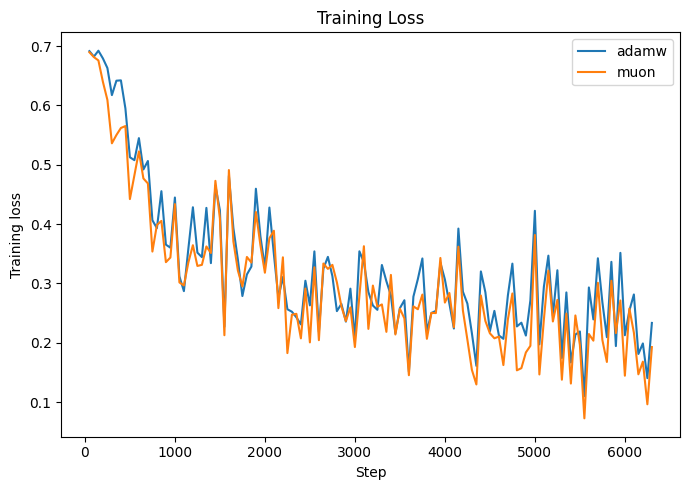

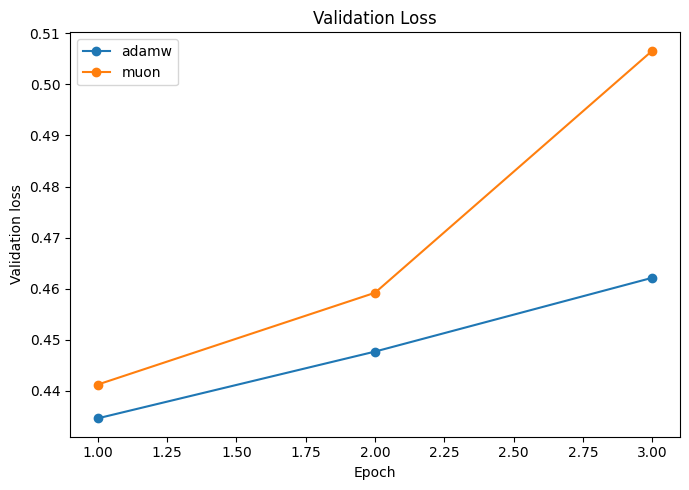

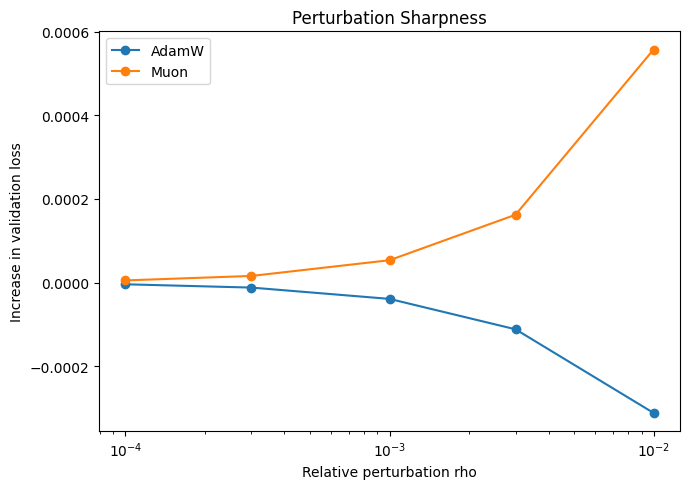


Saved results to: /kaggle/working/results
ZIP: /kaggle/working/results.zip


In [12]:
# ============================
# Final performance
# ============================

final_epoch = (
    epoch_metrics
    .sort_values("epoch")
    .groupby(
        ["optimizer", "seed"]
    )
    .tail(1)
)

summary = (
    final_epoch
    .groupby("optimizer")
    .agg(
        val_loss_mean=(
            "val_loss",
            "mean"
        ),
        val_loss_std=(
            "val_loss",
            "std"
        ),
        val_accuracy_mean=(
            "val_accuracy",
            "mean"
        ),
        val_accuracy_std=(
            "val_accuracy",
            "std"
        ),
        runtime_mean=(
            "runtime",
            "mean"
        )
    )
    .reset_index()
)

print("\nFINAL SUMMARY")
display(summary)


# ============================
# Optimization summary
# ============================

optimization_summary = (
    step_metrics
    .groupby("optimizer")
    .agg(
        grad_norm_mean=(
            "grad_norm",
            "mean"
        ),
        relative_update_mean=(
            "relative_update",
            "mean"
        )
    )
    .reset_index()
)

display(optimization_summary)


# ============================
# Sharpness summary
# ============================

sharpness_summary = (
    sharpness_df
    .groupby(
        ["optimizer", "rho"]
    )["mean_loss_increase"]
    .mean()
    .reset_index()
)

display(sharpness_summary)


# ============================
# Plot 1: training loss
# ============================

plt.figure(figsize=(7,5))

for opt in ["adamw", "muon"]:

    x = (
        step_metrics[
            step_metrics.optimizer == opt
        ]
        .groupby("step")
        .train_loss
        .mean()
    )

    plt.plot(
        x.index,
        x.values,
        label=opt
    )

plt.xlabel("Step")
plt.ylabel("Training loss")
plt.title("Training Loss")
plt.legend()
plt.tight_layout()

plt.savefig(
    f"{OUTPUT_DIR}/training_loss.png",
    dpi=200
)

plt.show()


# ============================
# Plot 2: validation loss
# ============================

plt.figure(figsize=(7,5))

for opt in ["adamw", "muon"]:

    x = (
        epoch_metrics[
            epoch_metrics.optimizer == opt
        ]
        .groupby("epoch")
        .val_loss
        .mean()
    )

    plt.plot(
        x.index,
        x.values,
        marker="o",
        label=opt
    )

plt.xlabel("Epoch")
plt.ylabel("Validation loss")
plt.title("Validation Loss")
plt.legend()
plt.tight_layout()

plt.savefig(
    f"{OUTPUT_DIR}/validation_loss.png",
    dpi=200
)

plt.show()


# ============================
# Plot 3: sharpness
# ============================

plt.figure(figsize=(7,5))

for opt in ["AdamW", "Muon"]:

    x = sharpness_summary[
        sharpness_summary.optimizer == opt
    ]

    plt.plot(
        x.rho,
        x.mean_loss_increase,
        marker="o",
        label=opt
    )

plt.xscale("log")
plt.xlabel("Relative perturbation rho")
plt.ylabel("Increase in validation loss")
plt.title("Perturbation Sharpness")
plt.legend()
plt.tight_layout()

plt.savefig(
    f"{OUTPUT_DIR}/sharpness.png",
    dpi=200
)

plt.show()


# ============================
# Save CSVs
# ============================

step_metrics.to_csv(
    f"{OUTPUT_DIR}/step_metrics.csv",
    index=False
)

epoch_metrics.to_csv(
    f"{OUTPUT_DIR}/epoch_metrics.csv",
    index=False
)

summary.to_csv(
    f"{OUTPUT_DIR}/summary.csv",
    index=False
)

sharpness_df.to_csv(
    f"{OUTPUT_DIR}/sharpness.csv",
    index=False
)

optimization_summary.to_csv(
    f"{OUTPUT_DIR}/optimization_summary.csv",
    index=False
)

adam_lr_results.to_csv(
    f"{OUTPUT_DIR}/adam_lr_search.csv",
    index=False
)

muon_lr_results.to_csv(
    f"{OUTPUT_DIR}/muon_lr_search.csv",
    index=False
)


# Zip all results
import shutil

shutil.make_archive(
    "/kaggle/working/results",
    "zip",
    OUTPUT_DIR
)

print(
    "\nSaved results to:",
    OUTPUT_DIR
)

print(
    "ZIP:",
    "/kaggle/working/results.zip"
)